# Phase 3 — Productionize the RFM Segmentation

The segmentation pipeline is now based on **RFM quintile scoring** (not K-Means clusters).

This notebook:
1. Re-runs the full pipeline cleanly on the full dataset
2. Saves the quintile boundaries as a reusable lookup table
3. Writes a `predict_segment()` function anyone can call with raw R, F, M values
4. Tests the function
5. Evaluates the final segment quality

### Why no pkl files for the model?

RFM scoring doesn't use a trained ML model — it uses **percentile boundaries learned from the data**.
We save those boundaries to a CSV so the dashboard can use them without retraining.

```
models/
    rfm_boundaries.csv   ← the quintile cutpoints for R, F, M

cc_kmeans_output.csv     ← customer table with all scores and segments
```

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

plt.style.use('ggplot')
print('Imports done.')

Imports done.


## Step 2 — Load and clean data

In [2]:
df = pd.read_csv('credit_card_transactions.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob']                   = pd.to_datetime(df['dob'], errors='coerce')
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25

for col in ['amt', 'age', 'city_pop']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print('Rows after outlier removal:', len(df))
print('Unique customers          :', df['cc_num'].nunique())

Rows after outlier removal: 1000070
Unique customers          : 781


## Step 3 — Build RFM table and assign quintile scores

In [3]:
ref_date = df['trans_date_trans_time'].max() + pd.Timedelta(days=1)

rfm = df.groupby('cc_num').agg(
    Recency    = ('trans_date_trans_time', lambda x: (ref_date - x.max()).days),
    Frequency  = ('trans_num',  'count'),
    Monetary   = ('amt',        'sum'),
    Avg_Amt    = ('amt',        'mean'),
    Fraud_Rate = ('is_fraud',   'mean'),
).reset_index()

# Quintile scoring
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'),   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['FM_score']  = (rfm['F_score'] + rfm['M_score']) / 2

print('RFM table ready:', rfm.shape)

RFM table ready: (781, 11)


## Step 4 — Save the quintile boundary cutpoints

These are the actual dollar/day/transaction values at the 20th, 40th, 60th, 80th percentile.
A new customer's raw values are compared against these to assign their score.

In [4]:
os.makedirs('models', exist_ok=True)

# Compute the percentile cutpoints for each dimension
boundaries = {}
for col in ['Recency', 'Frequency', 'Monetary']:
    boundaries[col] = [
        rfm[col].quantile(0.20),
        rfm[col].quantile(0.40),
        rfm[col].quantile(0.60),
        rfm[col].quantile(0.80),
    ]

boundaries_df = pd.DataFrame(boundaries, index=['20th','40th','60th','80th'])
boundaries_df.to_csv('models/rfm_boundaries.csv')

print('Saved: models/rfm_boundaries.csv')
print()
print(boundaries_df.round(1).to_string())

Saved: models/rfm_boundaries.csv

      Recency  Frequency  Monetary
20th      1.0      495.0   25129.1
40th      1.0      990.0   49203.2
60th      1.0     1477.0   74466.8
80th      1.0     1976.0   96895.8


## Step 5 — Assign segments using the Putler 11-segment mapping

In [5]:
def assign_segment(r, fm):
    """Map R score + FM score (avg of F and M) to one of 11 named segments."""
    if   r >= 4 and fm >= 4:           return 'Champions'
    elif r <= 1 and fm >= 4:           return 'Cannot Lose Them'
    elif r <= 2 and fm >= 3:           return 'At Risk'
    elif r >= 3 and fm >= 3:           return 'Loyal Customers'
    elif r >= 4 and fm < 2:            return 'New Customers'
    elif r == 3 and fm < 2:            return 'Promising'
    elif 2 <= r <= 3 and 2 <= fm <= 3: return 'Needs Attention'
    elif 2 <= r <= 3 and fm < 2:       return 'About To Sleep'
    elif 1 <= r <= 2 and 1 <= fm <= 2: return 'Hibernating'
    elif r <= 2 and fm < 1:            return 'Lost'
    else:                              return 'Hibernating'

rfm['Segment'] = rfm.apply(lambda row: assign_segment(row['R_score'], row['FM_score']), axis=1)

print('Segment counts:')
print(rfm['Segment'].value_counts().to_string())

Segment counts:
Segment
Loyal Customers     176
Hibernating         174
Champions           133
At Risk             115
Needs Attention      71
New Customers        50
Promising            28
About To Sleep       21
Cannot Lose Them     13


## Step 6 — Write the predict function

This function takes raw customer values (days, transaction count, total spend) and returns their segment name.
It uses the boundary table to assign scores, then calls `assign_segment()`.

In [6]:
def get_score_from_boundaries(value, cutpoints, reverse=False):
    """
    Assign a 1-5 score based on where a value sits relative to 4 cutpoints.
    reverse=True means lower value = higher score (used for Recency).
    """
    p20, p40, p60, p80 = cutpoints
    if reverse:
        if   value <= p20: return 5
        elif value <= p40: return 4
        elif value <= p60: return 3
        elif value <= p80: return 2
        else:              return 1
    else:
        if   value <= p20: return 1
        elif value <= p40: return 2
        elif value <= p60: return 3
        elif value <= p80: return 4
        else:              return 5


def predict_segment(recency_days, frequency, monetary_usd):
    """
    Predict which RFM segment a customer belongs to.

    Parameters
    ----------
    recency_days  : int   — days since last transaction
    frequency     : int   — total number of transactions
    monetary_usd  : float — total spend in USD

    Returns
    -------
    dict with keys: R_score, F_score, M_score, FM_score, RFM_score, Segment
    """
    bounds = pd.read_csv('models/rfm_boundaries.csv', index_col=0)

    r = get_score_from_boundaries(recency_days,  bounds['Recency'].values,   reverse=True)
    f = get_score_from_boundaries(frequency,     bounds['Frequency'].values,  reverse=False)
    m = get_score_from_boundaries(monetary_usd,  bounds['Monetary'].values,   reverse=False)

    fm  = (f + m) / 2
    seg = assign_segment(r, fm)

    return {
        'R_score':   r,
        'F_score':   f,
        'M_score':   m,
        'FM_score':  fm,
        'RFM_score': r + f + m,
        'Segment':   seg,
    }


print('predict_segment() is ready.')

predict_segment() is ready.


## Step 7 — Test the function on known customers

In [7]:
test_cases = [
    (1,   2500, 120000, 'Active, very high freq, very high spend → expect Champions or Loyal'),
    (300, 3,    60,     'Inactive 10 months, barely any activity → expect Hibernating or At Risk'),
    (1,   1200, 60000,  'Active, moderate freq and spend         → expect Loyal or Needs Attention'),
    (1,   400,  24000,  'Active, low freq and spend              → expect Promising or Needs Attention'),
    (1,   2,    150,    'Brand new or nearly new customer         → expect New Customers'),
]

print('Testing predict_segment():')
print()
for recency, freq, monetary, description in test_cases:
    result = predict_segment(recency, freq, monetary)
    print(f'  R={recency:3d} days  F={freq:4d} txns  M=${monetary:>7,}')
    print(f'  Scores: R={result["R_score"]}  F={result["F_score"]}  M={result["M_score"]}  FM={result["FM_score"]}  Total={result["RFM_score"]}')
    print(f'  → {result["Segment"]}')
    print(f'  → {description}')
    print()

Testing predict_segment():

  R=  1 days  F=2500 txns  M=$120,000
  Scores: R=5  F=5  M=5  FM=5.0  Total=15
  → Champions
  → Active, very high freq, very high spend → expect Champions or Loyal

  R=300 days  F=   3 txns  M=$     60
  Scores: R=1  F=1  M=1  FM=1.0  Total=3
  → Hibernating
  → Inactive 10 months, barely any activity → expect Hibernating or At Risk

  R=  1 days  F=1200 txns  M=$ 60,000
  Scores: R=5  F=3  M=3  FM=3.0  Total=11
  → Loyal Customers
  → Active, moderate freq and spend         → expect Loyal or Needs Attention

  R=  1 days  F= 400 txns  M=$ 24,000
  Scores: R=5  F=1  M=1  FM=1.0  Total=7
  → New Customers
  → Active, low freq and spend              → expect Promising or Needs Attention

  R=  1 days  F=   2 txns  M=$    150
  Scores: R=5  F=1  M=1  FM=1.0  Total=7
  → New Customers
  → Brand new or nearly new customer         → expect New Customers



## Step 8 — Save the full customer table

In [8]:
rfm.to_csv('cc_kmeans_output.csv', index=False)

print('Saved: cc_kmeans_output.csv')
print('Columns:', rfm.columns.tolist())
print('Rows:',    len(rfm))

Saved: cc_kmeans_output.csv
Columns: ['cc_num', 'Recency', 'Frequency', 'Monetary', 'Avg_Amt', 'Fraud_Rate', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'FM_score', 'Segment']
Rows: 781


## Step 9 — Evaluation: segment quality checks

In [9]:
COLORS = {
    'Champions':          '#1D9E75',
    'Loyal Customers':    '#2E75B6',
    'Potential Loyalist': '#27AE60',
    'New Customers':      '#3498DB',
    'Promising':          '#F39C12',
    'Needs Attention':    '#E67E22',
    'About To Sleep':     '#E74C3C',
    'At Risk':            '#C0392B',
    'Cannot Lose Them':   '#8E44AD',
    'Hibernating':        '#7F8C8D',
    'Lost':               '#95A5A6',
}

profile = rfm.groupby('Segment').agg(
    Customers = ('cc_num','count'),
    Avg_R     = ('R_score','mean'),
    Avg_F     = ('F_score','mean'),
    Avg_M     = ('M_score','mean'),
    Avg_RFM   = ('RFM_Score','mean'),
    Med_Recency   = ('Recency','median'),
    Med_Frequency = ('Frequency','median'),
    Med_Monetary  = ('Monetary','median'),
).round(2).sort_values('Avg_RFM', ascending=False)

print('SEGMENT QUALITY PROFILE')
print(profile.to_string())

SEGMENT QUALITY PROFILE
                  Customers  Avg_R  Avg_F  Avg_M  Avg_RFM  Med_Recency  Med_Frequency  Med_Monetary
Segment                                                                                            
Champions               133   4.53   4.53   4.59    13.65          1.0         1980.0     101509.74
Loyal Customers         176   3.64   3.66   3.71    11.01          1.0         1477.0      74629.46
Cannot Lose Them         13   1.00   4.46   4.46     9.92          1.0         1974.0      96895.78
At Risk                 115   1.83   4.03   3.98     9.84          1.0         1524.0      83610.43
New Customers            50   4.60   1.28   1.22     7.10          1.0          490.5      23845.94
Needs Attention          71   2.45   2.27   2.23     6.94          1.0          976.0      46397.91
Promising                28   3.00   1.39   1.21     5.61          1.0          491.0      23689.04
Hibernating             174   1.99   1.65   1.62     5.26          2.0      

In [10]:
# Check 1 — RFM score ordering makes sense
print('Business sense checks:')
print()

checks = [
    ('Champions have highest avg RFM score',
     'Champions' in profile.index and profile.loc['Champions','Avg_RFM'] == profile['Avg_RFM'].max()),
    ('Champions have highest avg R score',
     'Champions' in profile.index and profile.loc['Champions','Avg_R'] >= 4.0),
    ('Champions have highest avg F score',
     'Champions' in profile.index and profile.loc['Champions','Avg_F'] >= 4.0),
    ('At Risk have low R score (gone quiet)',
     'At Risk' in profile.index and profile.loc['At Risk','Avg_R'] <= 2.5),
    ('Hibernating have low scores across all dimensions',
     'Hibernating' in profile.index and profile.loc['Hibernating','Avg_RFM'] <= 7.0),
    ('No segment has more than 50% of all customers',
     profile['Customers'].max() / len(rfm) < 0.50),
]

all_pass = True
for label, passed in checks:
    icon = '✅' if passed else '❌'
    print(f'  {icon} {label}')
    if not passed:
        all_pass = False

print()
if all_pass:
    print('All checks passed — the segmentation is working correctly.')
else:
    print('Some checks failed. Review the segment mapping logic.')

Business sense checks:

  ✅ Champions have highest avg RFM score
  ✅ Champions have highest avg R score
  ✅ Champions have highest avg F score
  ✅ At Risk have low R score (gone quiet)
  ✅ Hibernating have low scores across all dimensions
  ✅ No segment has more than 50% of all customers

All checks passed — the segmentation is working correctly.


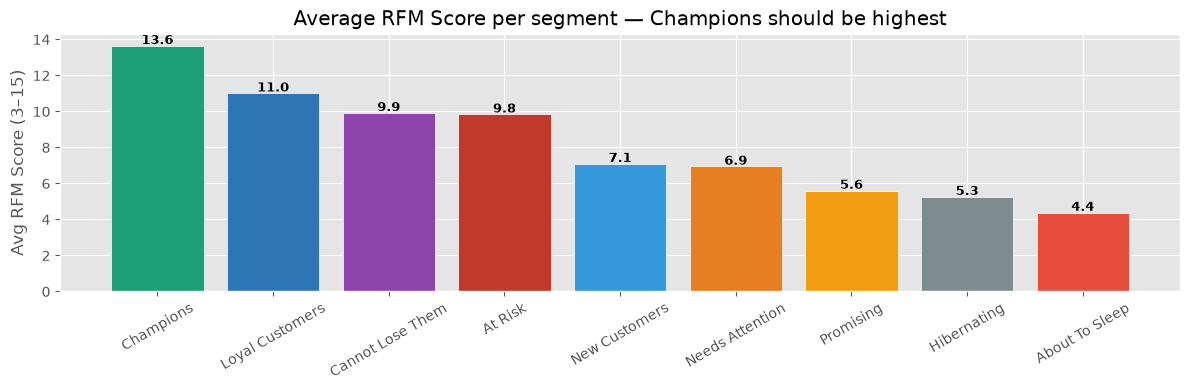

In [11]:
# Check 2 — Visual: RFM score per segment
seg_scores = rfm.groupby('Segment')['RFM_Score'].mean().sort_values(ascending=False)
colors_ordered = [COLORS.get(s,'#888') for s in seg_scores.index]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(seg_scores.index, seg_scores.values, color=colors_ordered, edgecolor='white')
ax.set_ylabel('Avg RFM Score (3–15)')
ax.set_title('Average RFM Score per segment — Champions should be highest')
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, seg_scores.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

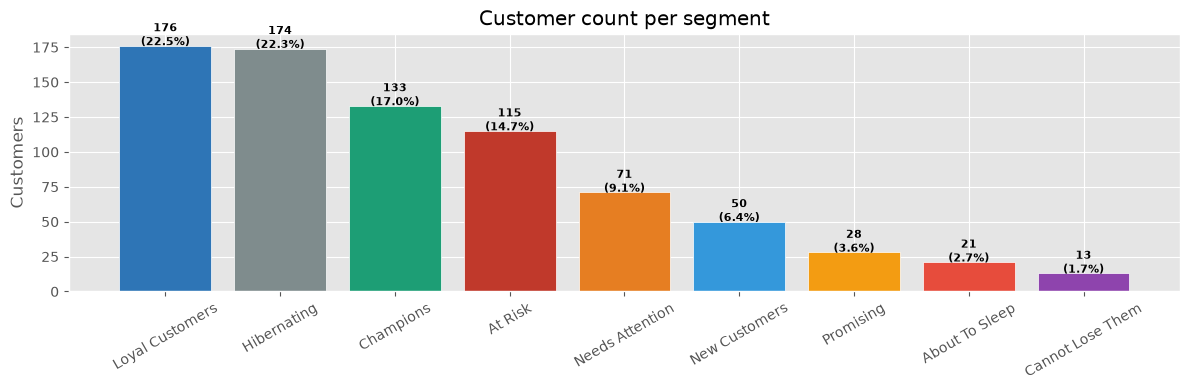

In [12]:
# Check 3 — Segment size balance
counts = rfm['Segment'].value_counts()
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS.get(s,'#888') for s in counts.index], edgecolor='white')
ax.set_ylabel('Customers')
ax.set_title('Customer count per segment')
ax.tick_params(axis='x', rotation=30)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / len(rfm) * 100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{cnt}\n({pct:.1f}%)', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary — what you now have

```
models/
    rfm_boundaries.csv   ← percentile cutpoints for R, F, M scoring

cc_kmeans_output.csv     ← every customer with scores and segment label
```

**How the dashboard uses these:**
- Loads `cc_kmeans_output.csv` directly (pre-scored)
- Uses `assign_segment(r, fm)` for the Predict page (no CSV lookup needed)
- All segment logic is deterministic — same input always gives same segment

**How to classify a new customer:**
```python
result = predict_segment(recency_days=5, frequency=800, monetary_usd=40000)
print(result['Segment'])  # 'Needs Attention'
```